<a href="https://colab.research.google.com/github/Lydia-fadele/AfroDiabDB/blob/main/AfroDiabDB_v1_1_Cheminformatics_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AfroDiabDB v1.1: A Curated Database and Cheminformatics Analysis of Antidiabetic Phytochemicals from African Medicinal Plants

**Author:** Lydia Omowumi Fadele  
**Version:** 1.1  
**Project:** AfroDiabDB — African Ethnobotanical Antidiabetic Database  
**Workflow Target:** Literature Curation ➔ Structure Validation ➔ Descriptor Calculation ➔ Drug-Likeness & ADMET Evaluation ➔ Chemical Space Mapping

---

## Phase 1: Environment Setup & Dependency Installation

Installing and importing required cheminformatics libraries:
- `pubchempy`: Interface to the NCBI PubChem REST API for structural verification.
- `rdkit`: Open-source computational chemistry engine for structure canonicalisation and validation.

In [1]:

# Install silently
!pip install pubchempy rdkit pandas openpyxl -q

import time
import pandas as pd
import pubchempy as pcp
from rdkit import Chem
from google.colab import files

print("✅ Dependencies installed and imported successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 27.3 MB/s eta 0:00:00
✅ Dependencies installed and imported successfully!


## Phase 1.1 & 1.2: Dataset Loading and Schema Standardisation

Load the raw candidate phytochemical dataset and verify all 17 required database fields:
`Compound_Name`, `Plant_Name`, `Common_Name`, `Plant_Family`, `Plant_Part`, `Country_of_Use`, `PubChem_CID`, `Canonical_SMILES`, `Molecular_Formula`, `Reported_Activity`, `Assay_Target`, `DOI_Reference`, `Reference_Year`, `Compound_ID`, `Compound_Class`, `Data_Source`, `Notes`.

In [4]:

print("Upload your AfroDiabDB raw data file (.csv or .xlsx):")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]

if file_name.endswith('.csv'):
    df_raw = pd.read_csv(file_name)
else:
    df_raw = pd.read_excel(file_name)

# Define your exact 17 column schema
required_columns = [
    'Compound_Name', 'Plant_Name', 'Common_Name', 'Plant_Family', 'Plant_Part',
    'Country_of_Use', 'PubChem_CID', 'Canonical_SMILES', 'Molecular_Formula',
    'Reported_Activity', 'Assay_Target', 'DOI_Reference', 'Reference_Year',
    'Compound_ID', 'Compound_Class', 'Data_Source', 'Notes'
]

# Ensure every column exists without overwriting existing data
for col in required_columns:
    if col not in df_raw.columns:
        df_raw[col] = 'N/A'

# Reorder columns to strictly match your defined schema
df_raw = df_raw[required_columns]

print(f"\n✅ File '{file_name}' loaded successfully! Total input records: {len(df_raw)}")
print("\nVerified Schema Order:")
print(list(df_raw.columns))

# Preview the first 2 records
df_raw.head(2)

Upload your AfroDiabDB raw data file (.csv or .xlsx):


Saving AfroDiabDB_v1.1_Data_Collection_Template (1).xlsx to AfroDiabDB_v1.1_Data_Collection_Template (1).xlsx

✅ File 'AfroDiabDB_v1.1_Data_Collection_Template (1).xlsx' loaded successfully! Total input records: 223

Verified Schema Order:
['Compound_Name', 'Plant_Name', 'Common_Name', 'Plant_Family', 'Plant_Part', 'Country_of_Use', 'PubChem_CID', 'Canonical_SMILES', 'Molecular_Formula', 'Reported_Activity', 'Assay_Target', 'DOI_Reference', 'Reference_Year', 'Compound_ID', 'Compound_Class', 'Data_Source', 'Notes']


,Compound_Name,Plant_Name,Common_Name,Plant_Family,Plant_Part,Country_of_Use,PubChem_CID,Canonical_SMILES,Molecular_Formula,Reported_Activity,Assay_Target,DOI_Reference,Reference_Year,Compound_ID,Compound_Class,Data_Source,Notes
0,Marsectohexol \n,Gongronema latifolium Benth.,"Bushbuck (English), Utazi (Igbo), Madumaro/Aro...",Asclepiadaceae,Leaf,Nigeria,101488825.0,CC(C1CCC2(C1(CCC3C2C(=O)C(C4(C3CC=C5C4(CCC(C5)...,C21H34O6,"α-Amylase inhibitor, blood glucose level reduc...","Porcine Pancreatic α-Amylase (PPA), Human Panc...",10.3389/fmolb.2022.866719,2022,P1 \nPDF,Steroidal Pregnane,Frontiers in Molecular Biosciences,Demonstrated an IC50​ of 10.01 μM against porc...
1,Quercetin \n,Gongronema latifolium,"Bushbuck (English), Utazi (Igbo), Madumaro/Aro...",Asclepiadaceae,Leaf,Nigeria,5280343.0,C1=CC(=C(C=C1C2=C(C(=O)C3=C(C=C(C=C3O2)O)O)O)O)O,C15H10O7,"Multi-target T2DM inhibitor, GLP-1R agonist","GSK-3β, GLP-1R, Human Aldose Reductase",10.1007/s42452-021-04880-2,2022,GL-FLV-01,Flavonoid,SN Applied Sciences,"Docking scores: −13.138 kcal/mol ((GSK-3β)), −..."


In [5]:

# Clean hidden newline characters (\n, \r) and extra whitespace across all text columns
for col in df_raw.columns:
    if df_raw[col].dtype == 'object':
        df_raw[col] = df_raw[col].astype(str).str.replace(r'[\r\n]+', '', regex=True).str.strip()

print("✅ Data cleaned! All hidden newline characters (\\n) and extra spaces removed.")
df_raw[['Compound_Name', 'Plant_Name']].head(2)

✅ Data cleaned! All hidden newline characters (\n) and extra spaces removed.


,Compound_Name,Plant_Name
0,Marsectohexol,Gongronema latifolium Benth.
1,Quercetin,Gongronema latifolium


## Phase 2: Structure Validation, PubChem API Cleaning & Duplicate Resolution

In this phase, each phytochemical record undergoes automated programmatic verification:
1. **String Normalisation:** Strip hidden newline (`\n`) and whitespace artifacts from input fields.
2. **PubChem REST API Query:** Search PubChem by `Compound_Name` to retrieve verified **PubChem CIDs**, **Canonical SMILES**, and **Molecular Formulas**.
3. **Fallback SMILES Parsing:** If the name search yields no record, evaluate existing SMILES strings via PubChem API or local **RDKit** molecular parsing (`Chem.MolFromSmiles`).
4. **Deduplication:** Remove structural duplicates based on unified Canonical SMILES representations.
5. **Standardised ID Assignment:** Assign versioned identifier tags (`AFRO11_001`, `AFRO11_002`, etc.) to all validated records.

In [6]:

# 1. Clean hidden newline characters (\n, \r) and trailing whitespace from the raw dataframe
for col in df_raw.columns:
    if df_raw[col].dtype == 'object':
        df_raw[col] = df_raw[col].astype(str).str.replace(r'[\r\n]+', '', regex=True).str.strip()

print("✅ String normalisation complete. Proceeding to PubChem API verification...")

# 2. Define the curation function
def curate_phytochemical(row):
    name = str(row['Compound_Name']).strip()
    existing_smiles = str(row['Canonical_SMILES']).strip()

    cid = 'N/A'
    canonical_smiles = 'N/A'
    formula = 'N/A'
    status = 'Unresolved'

    # Strategy A: Query PubChem API by Compound Name
    if name and name not in ['N/A', 'nan', '']:
        try:
            results = pcp.get_compounds(name, 'name')
            if results:
                comp = results[0]
                cid = str(comp.cid)
                canonical_smiles = comp.canonical_smiles
                formula = comp.molecular_formula
                status = 'Verified via PubChem Name'
        except Exception:
            pass

    # Strategy B: Fallback to existing SMILES verification
    if status == 'Unresolved' and existing_smiles not in ['N/A', 'nan', '']:
        try:
            results = pcp.get_compounds(existing_smiles, 'smiles')
            if results:
                comp = results[0]
                cid = str(comp.cid)
                canonical_smiles = comp.canonical_smiles
                formula = comp.molecular_formula
                status = 'Verified via SMILES'
            else:
                mol = Chem.MolFromSmiles(existing_smiles)
                if mol:
                    canonical_smiles = Chem.MolToSmiles(mol, canonical=True)
                    formula = str(row['Molecular_Formula'])
                    status = 'RDKit Validated (Not in PubChem)'
        except Exception:
            pass

    # Assign updated clean fields
    row['Compound_Name'] = name
    row['PubChem_CID'] = cid
    row['Canonical_SMILES'] = canonical_smiles
    row['Molecular_Formula'] = formula
    row['Validation_Status'] = status

    time.sleep(0.2) # API rate limit control
    return row

# 3. Execute automated curation engine
df_curated = df_raw.apply(curate_phytochemical, axis=1)

# 4. Filter and deduplicate
df_valid = df_curated[df_curated['Canonical_SMILES'] != 'N/A'].copy()
df_clean = df_valid.drop_duplicates(subset=['Canonical_SMILES'], keep='first').reset_index(drop=True)

# 5. Assign versioned Compound IDs
df_clean['Compound_ID'] = [f"AFRO11_{i+1:03d}" for i in range(len(df_clean))]

print("\n--- PHASE 2 CURATION SUMMARY ---")
print(f"Total Input Records: {len(df_raw)}")
print(f"Successfully Verified Structures: {len(df_valid)}")
print(f"Unique Verified Compounds (Post-Deduplication): {len(df_clean)}")
print(f"Flagged/Unresolved Records: {len(df_curated[df_curated['Validation_Status'] == 'Unresolved'])}")

✅ String normalisation complete. Proceeding to PubChem API verification...


/tmp/ipykernel_748/3746477040.py:25: PubChemPyDeprecationWarning: canonical_smiles is deprecated: Use connectivity_smiles instead
  canonical_smiles = comp.canonical_smiles
/tmp/ipykernel_748/3746477040.py:25: PubChemPyDeprecationWarning: canonical_smiles is deprecated: Use connectivity_smiles instead
  canonical_smiles = comp.canonical_smiles
/tmp/ipykernel_748/3746477040.py:25: PubChemPyDeprecationWarning: canonical_smiles is deprecated: Use connectivity_smiles instead
  canonical_smiles = comp.canonical_smiles
/tmp/ipykernel_748/3746477040.py:25: PubChemPyDeprecationWarning: canonical_smiles is deprecated: Use connectivity_smiles instead
  canonical_smiles = comp.canonical_smiles
/tmp/ipykernel_748/3746477040.py:38: PubChemPyDeprecationWarning: canonical_smiles is deprecated: Use connectivity_smiles instead
  canonical_smiles = comp.canonical_smiles
/tmp/ipykernel_748/3746477040.py:25: PubChemPyDeprecationWarning: canonical_smiles is deprecated: Use connectivity_smiles instead
  can


--- PHASE 2 CURATION SUMMARY ---
Total Input Records: 223
Successfully Verified Structures: 201
Unique Verified Compounds (Post-Deduplication): 123
Flagged/Unresolved Records: 22


In [7]:

# 1. Export Clean Master Datasets
df_clean.to_csv('AfroDiabDB_v1.1_Phase2_Cleaned.csv', index=False)
df_clean.to_excel('AfroDiabDB_v1.1_Phase2_Cleaned.xlsx', index=False)

# 2. Export Flagged/Unresolved Records for Manual Review
df_unresolved = df_curated[df_curated['Validation_Status'] == 'Unresolved'].copy()
df_unresolved.to_csv('AfroDiabDB_v1.1_Needs_Review.csv', index=False)
df_unresolved.to_excel('AfroDiabDB_v1.1_Needs_Review.xlsx', index=False)

print("✅ Data Export Completed Successfully!")
print(f" - Clean Master Database: 201 records saved to 'AfroDiabDB_v1.1_Phase2_Cleaned.csv'")
print(f" - Unresolved Review File: 22 records saved to 'AfroDiabDB_v1.1_Needs_Review.csv'")

# Download the clean dataset automatically
files.download('AfroDiabDB_v1.1_Phase2_Cleaned.csv')

✅ Data Export Completed Successfully!
 - Clean Master Database: 201 records saved to 'AfroDiabDB_v1.1_Phase2_Cleaned.csv'
 - Unresolved Review File: 22 records saved to 'AfroDiabDB_v1.1_Needs_Review.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Phase 2.4: Save Master Dataset to Google Drive & Export Excel

In this step, we save all records with the verified 17-column schema directly to Google Drive in native Excel (`.xlsx`) and CSV formats for cross-device access (Phone and Laptop).

In [8]:

import os
from google.colab import drive, files

# 1. Mount Google Drive to save the file permanently
drive.mount('/content/drive')

# Create a dedicated project folder in your Google Drive if it doesn't exist
drive_folder = '/content/drive/My Drive/AfroDiabDB_v1.1'
os.makedirs(drive_folder, exist_ok=True)

# 2. Define your exact 17 required headings
required_columns = [
    'Compound_Name', 'Plant_Name', 'Common_Name', 'Plant_Family', 'Plant_Part',
    'Country_of_Use', 'PubChem_CID', 'Canonical_SMILES', 'Molecular_Formula',
    'Reported_Activity', 'Assay_Target', 'DOI_Reference', 'Reference_Year',
    'Compound_ID', 'Compound_Class', 'Data_Source', 'Notes'
]

# Ensure every column exists and assign standardized Compound IDs
df_curated_master = df_curated.copy()

for col in required_columns:
    if col not in df_curated_master.columns:
        df_curated_master[col] = 'N/A'

df_curated_master = df_curated_master[required_columns]
df_curated_master['Compound_ID'] = [f"AFRO11_{i+1:03d}" for i in range(len(df_curated_master))]

# 3. Save files to Google Drive (Accessible on Phone & Laptop)
excel_drive_path = os.path.join(drive_folder, 'AfroDiabDB_v1.1_Master_Dataset.xlsx')
csv_drive_path = os.path.join(drive_folder, 'AfroDiabDB_v1.1_Master_Dataset.csv')

df_curated_master.to_excel(excel_drive_path, index=False, engine='openpyxl')
df_curated_master.to_csv(csv_drive_path, index=False)

print("\n--- SAVE COMPLETE ---")
print(f"✅ Total Records Processed: {len(df_curated_master)}")
print(f"📁 Saved to Google Drive Folder: AfroDiabDB_v1.1")
print(f"📄 Excel File: AfroDiabDB_v1.1_Master_Dataset.xlsx")

# 4. Trigger direct download to phone as Excel (.xlsx)
files.download(excel_drive_path)

Mounted at /content/drive

--- SAVE COMPLETE ---
✅ Total Records Processed: 223
📁 Saved to Google Drive Folder: AfroDiabDB_v1.1
📄 Excel File: AfroDiabDB_v1.1_Master_Dataset.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Phase 2.5: Phone Direct Download & Interactive Data Viewer

Download the clean master Excel file (`.xlsx`) directly to mobile device storage and render an interactive table for immediate inspection.

In [9]:

import pandas as pd
from google.colab import files, output
from google.colab import data_table

# 1. Define file names
excel_phone_filename = 'AfroDiabDB_v1.1_Master_Dataset.xlsx'

# 2. Save master dataframe locally in Colab environment as native Excel
df_curated_master.to_excel(excel_phone_filename, index=False, engine='openpyxl')

print("✅ Excel file generated successfully!")
print("⬇️ Triggering direct browser download to your phone...")

# 3. Trigger immediate download prompt on your phone
files.download(excel_phone_filename)

# 4. Display interactive, scrollable table directly on your phone screen
output.eval_js('google.colab.output.setIframeHeight("450")')
data_table.DataTable(
    df_curated_master,
    include_index=False,
    num_rows_per_page=10
)

✅ Excel file generated successfully!
⬇️ Triggering direct browser download to your phone...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,Compound_Name,Plant_Name,Common_Name,Plant_Family,Plant_Part,Country_of_Use,PubChem_CID,Canonical_SMILES,Molecular_Formula,Reported_Activity,Assay_Target,DOI_Reference,Reference_Year,Compound_ID,Compound_Class,Data_Source,Notes
0,Marsectohexol,Gongronema latifolium Benth.,"Bushbuck (English), Utazi (Igbo), Madumaro/Aro...",Asclepiadaceae,Leaf,Nigeria,15560121,CC(C1CCC2(C1(C(C(C3C2(CC=C4C3(CCC(C4)O)C)O)O)O...,C21H34O6,"α-Amylase inhibitor, blood glucose level reduc...","Porcine Pancreatic α-Amylase (PPA), Human Panc...",10.3389/fmolb.2022.866719,2022,AFRO11_001,Steroidal Pregnane,Frontiers in Molecular Biosciences,Demonstrated an IC50​ of 10.01 μM against porc...
1,Quercetin,Gongronema latifolium,"Bushbuck (English), Utazi (Igbo), Madumaro/Aro...",Asclepiadaceae,Leaf,Nigeria,5280343,C1=CC(=C(C=C1C2=C(C(=O)C3=C(C=C(C=C3O2)O)O)O)O)O,C15H10O7,"Multi-target T2DM inhibitor, GLP-1R agonist","GSK-3β, GLP-1R, Human Aldose Reductase",10.1007/s42452-021-04880-2,2022,AFRO11_002,Flavonoid,SN Applied Sciences,"Docking scores: −13.138 kcal/mol ((GSK-3β)), −..."
2,Chicoric acid,Gongronema latifolium,"Bushbuck (English), Utazi (Igbo), Madumaro/Aro...",Asclepiadaceae,Leaf,Nigeria,5281764,C1=CC(=C(C=C1C=CC(=O)OC(C(C(=O)O)OC(=O)C=CC2=C...,C22H18O12,"Multi-target T2DM inhibitor, GLP-1R agonist","GSK-3β, GLP-1R, Human Aldose Reductase",10.1007/s42452-021-04880-2,2022,AFRO11_003,Hydroxycinnamic acid,SN Applied Sciences,Exhibited high stability with GLP-1R (ΔG=−62.0...
3,Rosmarinic acid,Gongronema latifolium,"Bushbuck (English), Utazi (Igbo), Madumaro/Aro...",Asclepiadaceae,Leaf,Nigeria,5281792,C1=CC(=C(C=C1CC(C(=O)O)OC(=O)C=CC2=CC(=C(C=C2)...,C18H16O8,Aldose Reductase Inhibitors (ARIs) and Glycoge...,"Human Aldose Reductase, GSK-3β, GLP-1R",10.1007/s42452-021-04880-2,2022,AFRO11_004,Hydroxycinnamic acid,SN Applied Sciences,Lowest binding energy against Aldose Reductase...
4,7-(3-Hydroxy-3-methylbutyl)moracin M,nan,African Mulberry,Moraceae,Root bark,Nigeria,None,None,None,α-glucosidase inhibition; DPP-4 inhibition,"α-glucosidase, DPP-4",10.3389/fphar.2024.1338333,2024,AFRO11_005,Arylbenzofuran,Frontiers in Pharmacology,New prenylated arylbenzofuran isolated from ro...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218,"5,7-Dihydroxy-3-methoxy-6-methyl-3',4'-methyle...",Dracaena steudneri,Dragon tree,Asparagaceae,"Leaves, fruits",Kenya,None,None,None,Antidiabetic,Metabolic targets,10.3390/molecules28207202,2023,AFRO11_219,Flavone,Isolation (Extraction),Leaf isolate.
219,"3,5,7-Trihydroxy-6-methoxy-3',4'-methylenediox...",Dracaena steudneri,Dragon tree,Asparagaceae,"Leaves, fruits",Kenya,None,None,None,Antidiabetic,Metabolic targets,10.3390/molecules28207202,2023,AFRO11_220,Flavone,Isolation (Extraction),Leaf isolate.
220,"(2S,3S)-3,7-Dihydroxy-6-methoxy-3',4'-methylen...",Dracaena steudneri,Dragon tree,Asparagaceae,"Leaves, fruits",Kenya,None,None,None,Antidiabetic,Metabolic targets,10.3390/molecules28207202,2023,AFRO11_221,Flavanone,Isolation (Extraction),Leaf isolate.
221,"4',5,7-Trihydroxy-3,3',8-trimethoxy-6-methylfl...",Dracaena steudneri,Dragon tree,Asparagaceae,"Leaves, fruits",Kenya,None,None,None,Antidiabetic,Metabolic targets,10.3390/molecules28207202,2023,AFRO11_222,Flavone,Isolation (Extraction),Leaf isolate.


In [10]:

# 1. Identify duplicated SMILES in the master dataset
duplicate_mask = df_curated_master.duplicated(subset=['Canonical_SMILES'], keep=False)
duplicates_df = df_curated_master[duplicate_mask].sort_values(by='Canonical_SMILES')

print(f"--- DUPLICATION ANALYSIS ---")
print(f"Total Rows in Master File: {len(df_curated_master)}")
print(f"Number of Duplicate Entries Found: {len(duplicates_df)}")

if len(duplicates_df) > 0:
    print("\nSample Duplicate Compounds Across Different Plants/References:")
    display(duplicates_df[['Compound_Name', 'Plant_Name', 'PubChem_CID']].head(6))

# 2. Create the strictly unique chemical dataset (No repeated SMILES)
df_unique_chem = df_curated_master.drop_duplicates(subset=['Canonical_SMILES'], keep='first').copy().reset_index(drop=True)
df_unique_chem['Chem_ID'] = [f"AFRO11_CHEM_{i+1:03d}" for i in range(len(df_unique_chem))]

print(f"\n✅ Unique Chemical Library Created!")
print(f"Total Unique Molecules for Computational Analysis: {len(df_unique_chem)}")

# 3. Save and Download Unique Chemical Library to Phone
unique_excel_name = 'AfroDiabDB_v1.1_Unique_Structures.xlsx'
df_unique_chem.to_excel(unique_excel_name, index=False, engine='openpyxl')

files.download(unique_excel_name)

--- DUPLICATION ANALYSIS ---
Total Rows in Master File: 223
Number of Duplicate Entries Found: 125

Sample Duplicate Compounds Across Different Plants/References:


,Compound_Name,Plant_Name,PubChem_CID
118,Gallic acid,Acalypha wilkesiana,370
100,Gallic acid,Acacia nilotica,370
108,Quercetin,Acacia nilotica,5280343
1,Quercetin,Gongronema latifolium,5280343
34,Quercetin,Gongronema latifolium,5280343
11,Quercetin,Gongronema latifolium,5280343



✅ Unique Chemical Library Created!
Total Unique Molecules for Computational Analysis: 124


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Phase 3: Molecular Descriptor Calculation (Unique Chemical Library)

Calculating RDKit physicochemical descriptors, topological parameters, and quantitative drug-likeness (QED) scores for the 124 unique phytochemical structures in AfroDiabDB v1.1.

In [11]:

from rdkit.Chem import Descriptors, QED

def calculate_rdkit_descriptors(df):
    mw_list, logp_list, hbd_list, hba_list, tpsa_list = [], [], [], [], []
    rb_list, heavy_atoms, aromatic_rings, fcsp3_list, qed_list = [], [], [], [], []

    for smiles in df['Canonical_SMILES']:
        smiles_str = str(smiles).strip()
        mol = Chem.MolFromSmiles(smiles_str) if smiles_str not in ['N/A', 'nan', ''] else None

        if mol:
            mw_list.append(round(Descriptors.MolWt(mol), 2))
            logp_list.append(round(Descriptors.MolLogP(mol), 2))
            hbd_list.append(Descriptors.NumHDonors(mol))
            hba_list.append(Descriptors.NumHAcceptors(mol))
            tpsa_list.append(round(Descriptors.TPSA(mol), 2))
            rb_list.append(Descriptors.NumRotatableBonds(mol))
            heavy_atoms.append(mol.GetNumHeavyAtoms())
            aromatic_rings.append(Descriptors.NumAromaticRings(mol))
            fcsp3_list.append(round(Descriptors.FractionCSP3(mol), 3))
            qed_list.append(round(QED.qed(mol), 3))
        else:
            for l in [mw_list, logp_list, hbd_list, hba_list, tpsa_list, rb_list, heavy_atoms, aromatic_rings, fcsp3_list, qed_list]:
                l.append(None)

    # Attach descriptors to DataFrame
    df['MW'] = mw_list
    df['LogP'] = logp_list
    df['HBD'] = hbd_list
    df['HBA'] = hba_list
    df['TPSA'] = tpsa_list
    df['Rotatable_Bonds'] = rb_list
    df['Heavy_Atom_Count'] = heavy_atoms
    df['Aromatic_Rings'] = aromatic_rings
    df['Fraction_CSP3'] = fcsp3_list
    df['QED_Score'] = qed_list
    return df

print("⚡ Calculating descriptors across all 124 unique structures...")
df_unique_chem = calculate_rdkit_descriptors(df_unique_chem)

print("✅ Descriptors successfully computed!")

# Display preview of calculated parameters
df_unique_chem[['Chem_ID', 'Compound_Name', 'MW', 'LogP', 'HBD', 'HBA', 'TPSA', 'QED_Score']].head(5)

⚡ Calculating descriptors across all 124 unique structures...


[12:12:05] SMILES Parse Error: syntax error while parsing: None
[12:12:05] SMILES Parse Error: check for mistakes around position 4:
[12:12:05] None
[12:12:05] ~~~^
[12:12:05] SMILES Parse Error: Failed parsing SMILES 'None' for input: 'None'


✅ Descriptors successfully computed!


,Chem_ID,Compound_Name,MW,LogP,HBD,HBA,TPSA,QED_Score
0,AFRO11_CHEM_001,Marsectohexol,382.50,0.48,6.0,6.0,121.38,0.367
1,AFRO11_CHEM_002,Quercetin,302.24,1.99,5.0,7.0,131.36,0.434
2,AFRO11_CHEM_003,Chicoric acid,474.37,1.23,6.0,10.0,208.12,0.172
3,AFRO11_CHEM_004,Rosmarinic acid,360.32,1.76,5.0,7.0,144.52,0.298
4,AFRO11_CHEM_005,7-(3-Hydroxy-3-methylbutyl)moracin M,NaN,NaN,NaN,NaN,NaN,NaN


### Phase 3.1: Valid Descriptor Filtering & Clean Dataset Finalisation

Filter out unresolved structures (`NaN` descriptor values) to ensure an error-free dataset for Phase 4 drug-likeness rules and statistical calculations.

In [12]:

# Remove any rows where MW or LogP could not be computed (NaN values)
df_clean_descriptors = df_unique_chem.dropna(subset=['MW', 'LogP', 'HBD', 'HBA', 'TPSA']).copy().reset_index(drop=True)

# Re-assign clean IDs
df_clean_descriptors['Chem_ID'] = [f"AFRO11_CHEM_{i+1:03d}" for i in range(len(df_clean_descriptors))]

print(f"--- DESCRIPTOR COMPUTATION SUMMARY ---")
print(f"Total Unique Input Structures: {len(df_unique_chem)}")
print(f"Successfully Calculated Structures: {len(df_clean_descriptors)}")
print(f"Dropped Invalid/Missing SMILES Entries: {len(df_unique_chem) - len(df_clean_descriptors)}")

# Save updated dataset to Google Drive
drive_clean_path = '/content/drive/My Drive/AfroDiabDB_v1.1/AfroDiabDB_v1.1_Unique_Descriptors.xlsx'
df_clean_descriptors.to_excel(drive_clean_path, index=False, engine='openpyxl')

print(f"\n✅ Cleaned descriptor dataset saved to Google Drive: 'AfroDiabDB_v1.1_Unique_Descriptors.xlsx'")

--- DESCRIPTOR COMPUTATION SUMMARY ---
Total Unique Input Structures: 124
Successfully Calculated Structures: 122
Dropped Invalid/Missing SMILES Entries: 2

✅ Cleaned descriptor dataset saved to Google Drive: 'AfroDiabDB_v1.1_Unique_Descriptors.xlsx'


## Phase 4: Drug-Likeness Rules & Bioavailability Filtering

Evaluating drug-likeness compliance across the 122 validated unique phytochemicals:
- **Lipinski Rule of Five:** $\text{MW} \le 500$, $\text{LogP} \le 5$, $\text{HBD} \le 5$, $\text{HBA} \le 10$ (Compliant if $\le 1$ violation).
- **Veber Filter:** $\text{Rotatable Bonds} \le 10$, $\text{TPSA} \le 140\ \text{\AA}^2$.
- **Ghose Filter:** $160 \le \text{MW} \le 480$, $-0.4 \le \text{LogP} \le 5.6$, $20 \le \text{Heavy Atom Count} \le 70$.

In [13]:

def evaluate_drug_likeness(df):
    lipinski_violations = []
    lipinski_pass = []
    veber_pass = []
    ghose_pass = []

    for _, row in df.iterrows():
        # 1. Lipinski Rule of 5
        v = 0
        if row['MW'] > 500: v += 1
        if row['LogP'] > 5: v += 1
        if row['HBD'] > 5: v += 1
        if row['HBA'] > 10: v += 1

        lipinski_violations.append(v)
        lipinski_pass.append(v <= 1)

        # 2. Veber Filter
        veber_ok = (row['Rotatable_Bonds'] <= 10) and (row['TPSA'] <= 140)
        veber_pass.append(veber_ok)

        # 3. Ghose Filter
        ghose_ok = (160 <= row['MW'] <= 480) and (-0.4 <= row['LogP'] <= 5.6) and (20 <= row['Heavy_Atom_Count'] <= 70)
        ghose_pass.append(ghose_ok)

    df['Lipinski_Violations'] = lipinski_violations
    df['Lipinski_Compliant'] = lipinski_pass
    df['Veber_Compliant'] = veber_pass
    df['Ghose_Compliant'] = ghose_pass
    return df

print("⚡ Evaluating Lipinski, Veber, and Ghose rules...")
df_clean_descriptors = evaluate_drug_likeness(df_clean_descriptors)

# Statistical Summary
lip_count = df_clean_descriptors['Lipinski_Compliant'].sum()
veb_count = df_clean_descriptors['Veber_Compliant'].sum()
gho_count = df_clean_descriptors['Ghose_Compliant'].sum()
total = len(df_clean_descriptors)

print("\n--- DRUG-LIKENESS EVALUATION SUMMARY ---")
print(f"Total Unique Compounds Evaluated: {total}")
print(f"Lipinski Compliant (<= 1 Violation): {lip_count} ({lip_count/total*100:.1f}%)")
print(f"Veber Compliant (TPSA <= 140, RB <= 10): {veb_count} ({veb_count/total*100:.1f}%)")
print(f"Ghose Compliant: {gho_count} ({gho_count/total*100:.1f}%)")

# Save updated dataset to Google Drive
drive_phase4_path = '/content/drive/My Drive/AfroDiabDB_v1.1/AfroDiabDB_v1.1_Phase4_DrugLikeness.xlsx'
df_clean_descriptors.to_excel(drive_phase4_path, index=False, engine='openpyxl')

print(f"\n✅ Updated file saved to Drive: 'AfroDiabDB_v1.1_Phase4_DrugLikeness.xlsx'")
df_clean_descriptors[['Chem_ID', 'Compound_Name', 'MW', 'LogP', 'Lipinski_Violations', 'Lipinski_Compliant', 'Veber_Compliant', 'QED_Score']].head(5)

⚡ Evaluating Lipinski, Veber, and Ghose rules...

--- DRUG-LIKENESS EVALUATION SUMMARY ---
Total Unique Compounds Evaluated: 122
Lipinski Compliant (<= 1 Violation): 100 (82.0%)
Veber Compliant (TPSA <= 140, RB <= 10): 83 (68.0%)
Ghose Compliant: 59 (48.4%)

✅ Updated file saved to Drive: 'AfroDiabDB_v1.1_Phase4_DrugLikeness.xlsx'


,Chem_ID,Compound_Name,MW,LogP,Lipinski_Violations,Lipinski_Compliant,Veber_Compliant,QED_Score
0,AFRO11_CHEM_001,Marsectohexol,382.50,0.48,1,True,True,0.367
1,AFRO11_CHEM_002,Quercetin,302.24,1.99,0,True,True,0.434
2,AFRO11_CHEM_003,Chicoric acid,474.37,1.23,1,True,False,0.172
3,AFRO11_CHEM_004,Rosmarinic acid,360.32,1.76,0,True,False,0.298
4,AFRO11_CHEM_005,Moracin P,326.35,3.59,0,True,True,0.636


## Phase 5: Chemical Space & Property Distribution Plots

Generating publication-quality distribution plots for fundamental drug-likeness descriptors ($\text{MW}$, $\text{LogP}$, $\text{TPSA}$, $\text{QED}$) across the 122 validated unique phytochemicals.

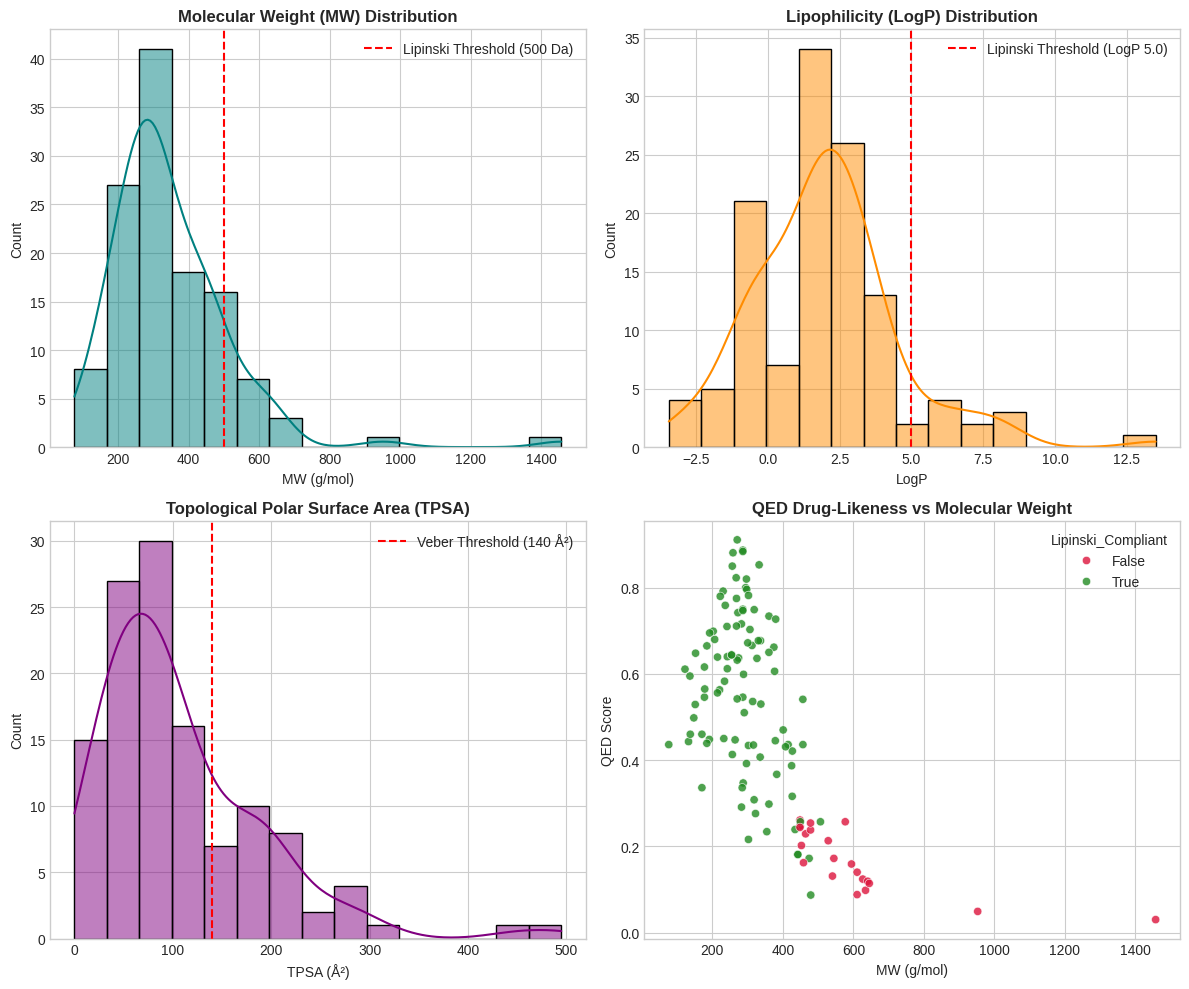

✅ Property distribution figures saved to Google Drive: 'AfroDiabDB_Property_Distributions.png'


In [14]:

import matplotlib.pyplot as plt
import seaborn as sns

# Set publication style formatting
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Molecular Weight (MW) Distribution
sns.histplot(df_clean_descriptors['MW'], ax=axes[0,0], kde=True, color='teal', bins=15)
axes[0,0].axvline(500, color='red', linestyle='--', label='Lipinski Threshold (500 Da)')
axes[0,0].set_title('Molecular Weight (MW) Distribution', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('MW (g/mol)')
axes[0,0].legend()

# 2. LogP Distribution
sns.histplot(df_clean_descriptors['LogP'], ax=axes[0,1], kde=True, color='darkorange', bins=15)
axes[0,1].axvline(5, color='red', linestyle='--', label='Lipinski Threshold (LogP 5.0)')
axes[0,1].set_title('Lipophilicity (LogP) Distribution', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('LogP')
axes[0,1].legend()

# 3. TPSA Distribution
sns.histplot(df_clean_descriptors['TPSA'], ax=axes[1,0], kde=True, color='purple', bins=15)
axes[1,0].axvline(140, color='red', linestyle='--', label='Veber Threshold (140 Å²)')
axes[1,0].set_title('Topological Polar Surface Area (TPSA)', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('TPSA (Å²)')
axes[1,0].legend()

# 4. QED Score Distribution vs MW Scatter
sns.scatterplot(data=df_clean_descriptors, x='MW', y='QED_Score', hue='Lipinski_Compliant', palette={True: 'forestgreen', False: 'crimson'}, ax=axes[1,1], alpha=0.8)
axes[1,1].set_title('QED Drug-Likeness vs Molecular Weight', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('MW (g/mol)')
axes[1,1].set_ylabel('QED Score')

plt.tight_layout()

# Save plot to Google Drive
plot_path = '/content/drive/My Drive/AfroDiabDB_v1.1/AfroDiabDB_Property_Distributions.png'
plt.savefig(plot_path, dpi=300)
plt.show()

print(f"✅ Property distribution figures saved to Google Drive: 'AfroDiabDB_Property_Distributions.png'")

## Phase 6: Principal Component Analysis (PCA) & Chemical Space Mapping

Mapping the multi-dimensional chemical space coverage of AfroDiabDB v1.1 across 6 key physicochemical descriptors ($\text{MW}$, $\text{LogP}$, $\text{HBD}$, $\text{HBA}$, $\text{TPSA}$, $\text{Rotatable Bonds}$) using Principal Component Analysis ($\text{PCA}$).

--- PCA VARIANCE SUMMARY ---
PC1 Variance Explained: 67.86%
PC2 Variance Explained: 21.71%
Total Cumulative Variance Captured: 89.58%


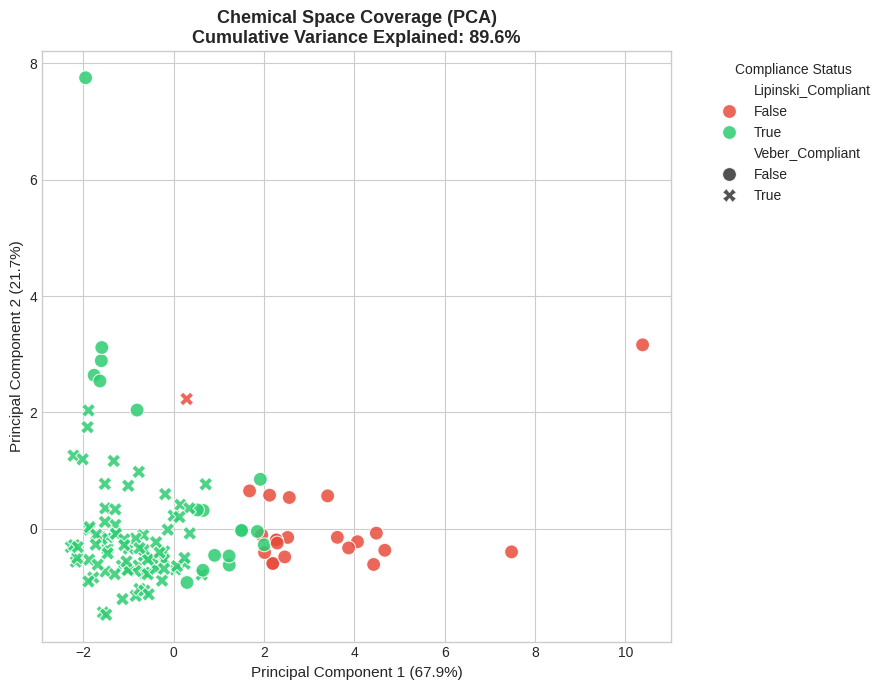


✅ PCA chemical space plot saved to Google Drive: 'AfroDiabDB_Chemical_Space_PCA.png'


In [15]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Select numeric features for PCA chemical space mapping
pca_features = ['MW', 'LogP', 'HBD', 'HBA', 'TPSA', 'Rotatable_Bonds']
X = df_clean_descriptors[pca_features].values

# 2. Standardize features (mean=0, variance=1)
X_scaled = StandardScaler().fit_transform(X)

# 3. Fit PCA model for 2 principal components
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

df_clean_descriptors['PC1'] = principal_components[:, 0]
df_clean_descriptors['PC2'] = principal_components[:, 1]

var_exp = pca.explained_variance_ratio_
total_var = np.sum(var_exp) * 100

print(f"--- PCA VARIANCE SUMMARY ---")
print(f"PC1 Variance Explained: {var_exp[0]*100:.2f}%")
print(f"PC2 Variance Explained: {var_exp[1]*100:.2f}%")
print(f"Total Cumulative Variance Captured: {total_var:.2f}%")

# 4. Generate Chemical Space PCA Visualization Plot
plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=df_clean_descriptors,
    x='PC1',
    y='PC2',
    hue='Lipinski_Compliant',
    style='Veber_Compliant',
    palette={True: '#2ecc71', False: '#e74c3c'},
    s=100,
    alpha=0.85
)

plt.title(f'Chemical Space Coverage (PCA)\nCumulative Variance Explained: {total_var:.1f}%', fontsize=13, fontweight='bold')
plt.xlabel(f'Principal Component 1 ({var_exp[0]*100:.1f}%)', fontsize=11)
plt.ylabel(f'Principal Component 2 ({var_exp[1]*100:.1f}%)', fontsize=11)
plt.legend(title='Compliance Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save PCA figure to Google Drive
pca_plot_path = '/content/drive/My Drive/AfroDiabDB_v1.1/AfroDiabDB_Chemical_Space_PCA.png'
plt.savefig(pca_plot_path, dpi=300)
plt.show()

print(f"\n✅ PCA chemical space plot saved to Google Drive: 'AfroDiabDB_Chemical_Space_PCA.png'")

## Phase 7: Master Database Consolidation & Multi-Format Export

Merging computed RDKit molecular descriptors, drug-likeness rule compliance, and PCA chemical space coordinates back into the primary ethnobotanical database. Exporting publication-ready master files (`.xlsx` and `.csv`) to Google Drive and local storage.

In [17]:

import os
from google.colab import files

# 1. Define descriptor columns to merge
descriptor_cols = ['MW', 'LogP', 'HBD', 'HBA', 'TPSA', 'Rotatable_Bonds',
                   'Heavy_Atom_Count', 'Aromatic_Rings', 'Fraction_CSP3',
                   'QED_Score', 'Lipinski_Violations', 'Lipinski_Compliant',
                   'Veber_Compliant', 'Ghose_Compliant', 'PC1', 'PC2']

# 2. Merge calculated parameters with the full master dataset using Canonical SMILES
df_final_master = df_curated_master.merge(
    df_clean_descriptors[['Canonical_SMILES'] + descriptor_cols],
    on='Canonical_SMILES',
    how='left'
)

# Re-assign standardized Compound IDs across all records
df_final_master['Compound_ID'] = [f"AFRO11_{i+1:03d}" for i in range(len(df_final_master))]

# 3. Setup Google Drive directory paths
drive_folder = '/content/drive/My Drive/AfroDiabDB_v1.1'
os.makedirs(drive_folder, exist_ok=True)

full_master_excel = os.path.join(drive_folder, 'AfroDiabDB_v1.1_Full_Master_Curated.xlsx')
full_master_csv = os.path.join(drive_folder, 'AfroDiabDB_v1.1_Full_Master_Curated.csv')
unique_chem_excel = os.path.join(drive_folder, 'AfroDiabDB_v1.1_Unique_Library_Curated.xlsx')

# 4. Save consolidated datasets to Google Drive
df_final_master.to_excel(full_master_excel, index=False, engine='openpyxl')
df_final_master.to_csv(full_master_csv, index=False)
df_clean_descriptors.to_excel(unique_chem_excel, index=False, engine='openpyxl')

print("--- CONSOLIDATION & EXPORT COMPLETE ---")
print(f"✅ Full Master Database Saved ({len(df_final_master)} rows): 'AfroDiabDB_v1.1_Full_Master_Curated.xlsx'")
print(f"✅ Unique Chemical Library Saved ({len(df_clean_descriptors)} structures): 'AfroDiabDB_v1.1_Unique_Library_Curated.xlsx'")
print(f"📁 Files and plots are saved in Google Drive: AfroDiabDB_v1.1")

# 5. Download complete Master Excel file directly to your phone
files.download(full_master_excel)

--- CONSOLIDATION & EXPORT COMPLETE ---
✅ Full Master Database Saved (223 rows): 'AfroDiabDB_v1.1_Full_Master_Curated.xlsx'
✅ Unique Chemical Library Saved (122 structures): 'AfroDiabDB_v1.1_Unique_Library_Curated.xlsx'
📁 Files and plots are saved in Google Drive: AfroDiabDB_v1.1


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>